In [2]:
# Setting the PythonPath
import os

# # Get the parent directory of the current working directory
parent_dir = os.path.dirname(os.path.dirname(os.getcwd()))
if "changed" not in locals():
    changed = False

if not changed:
    os.chdir(parent_dir)
    changed = True
print(os.getcwd())

%load_ext autoreload
%autoreload 2

/home/local/USHERBROOKE/aara2601/projects/shadow-quantum-kernels-gp


In [5]:
from data.synthetic import make_dataset
from data.synthetic import make_dataset, KernelConfig
from src.utils.settings import STORAGE_PATH
import pickle

kernel_cfgs = [
    KernelConfig(
        name="rbf",
        kernel_type="rbf",
        params={"lengthscale": 0.3},
    ),
    KernelConfig(
        name="matern32",
        kernel_type="matern32",
        params={"lengthscale": 0.3},
    ),
    KernelConfig(
        name="nonstat_ls",
        kernel_type="nonstat_ls",
        params={
            "ell_min": 0.1,
            "ell_max": 0.8,
            "c": 2.0,
            "ell_rest": 0.3,
        },
    ),
]


# M = 5 * (E - 1)
M = 500
# M = 20
input_dim = 1  # easiest for plotting
seed = 12345
noise_variance = 0.002

In [48]:
data = make_dataset(
    M=M,
    input_dim=input_dim,
    sampling="uniform",
    noise_variance=noise_variance,
    kernel_cfgs=kernel_cfgs,
    n_jobs=3,
    seed=seed,
)

In [7]:
file = os.path.join(STORAGE_PATH, "data", f"noisy={noise_variance}_n_gp={len(kernel_cfgs)}_M={M}_kernels=synth_rbf-matern32-amp_nonstat_ls.pkl")
with open(file, "wb") as f:
    pickle.dump(data, f)
    
X = data["inputs"]
Y = data["labels"]
X.shape, Y.shape

In [9]:
from src.utils.settings import STORAGE_PATH
import pickle

file = os.path.join(STORAGE_PATH, "data", f"noisy={noise_variance}_n_gp={len(kernel_cfgs)}_M={M}_kernels=synth_rbf-matern32-amp_nonstat_ls.pkl")

with open(file, "rb") as f:
    data = pickle.load(f)
    
X = data["inputs"]
Y = data["labels"]
X.shape, Y.shape

EOFError: Ran out of input

In [1]:
from viz.data.gp_plots import plot_gp_datasets

fig, axes = plot_gp_datasets(data, kernel_cfgs, x_dim=0, sort_by_x=True)

fig_file = os.path.join(STORAGE_PATH, "data", "figs", f"noisy={noise_variance}_M={M}_rbf_mater32_nonstat_ls_test_mean.pdf")

fig.savefig(fig_file, format="pdf", bbox_inches="tight")

ModuleNotFoundError: No module named 'viz'

## Generating an experiment

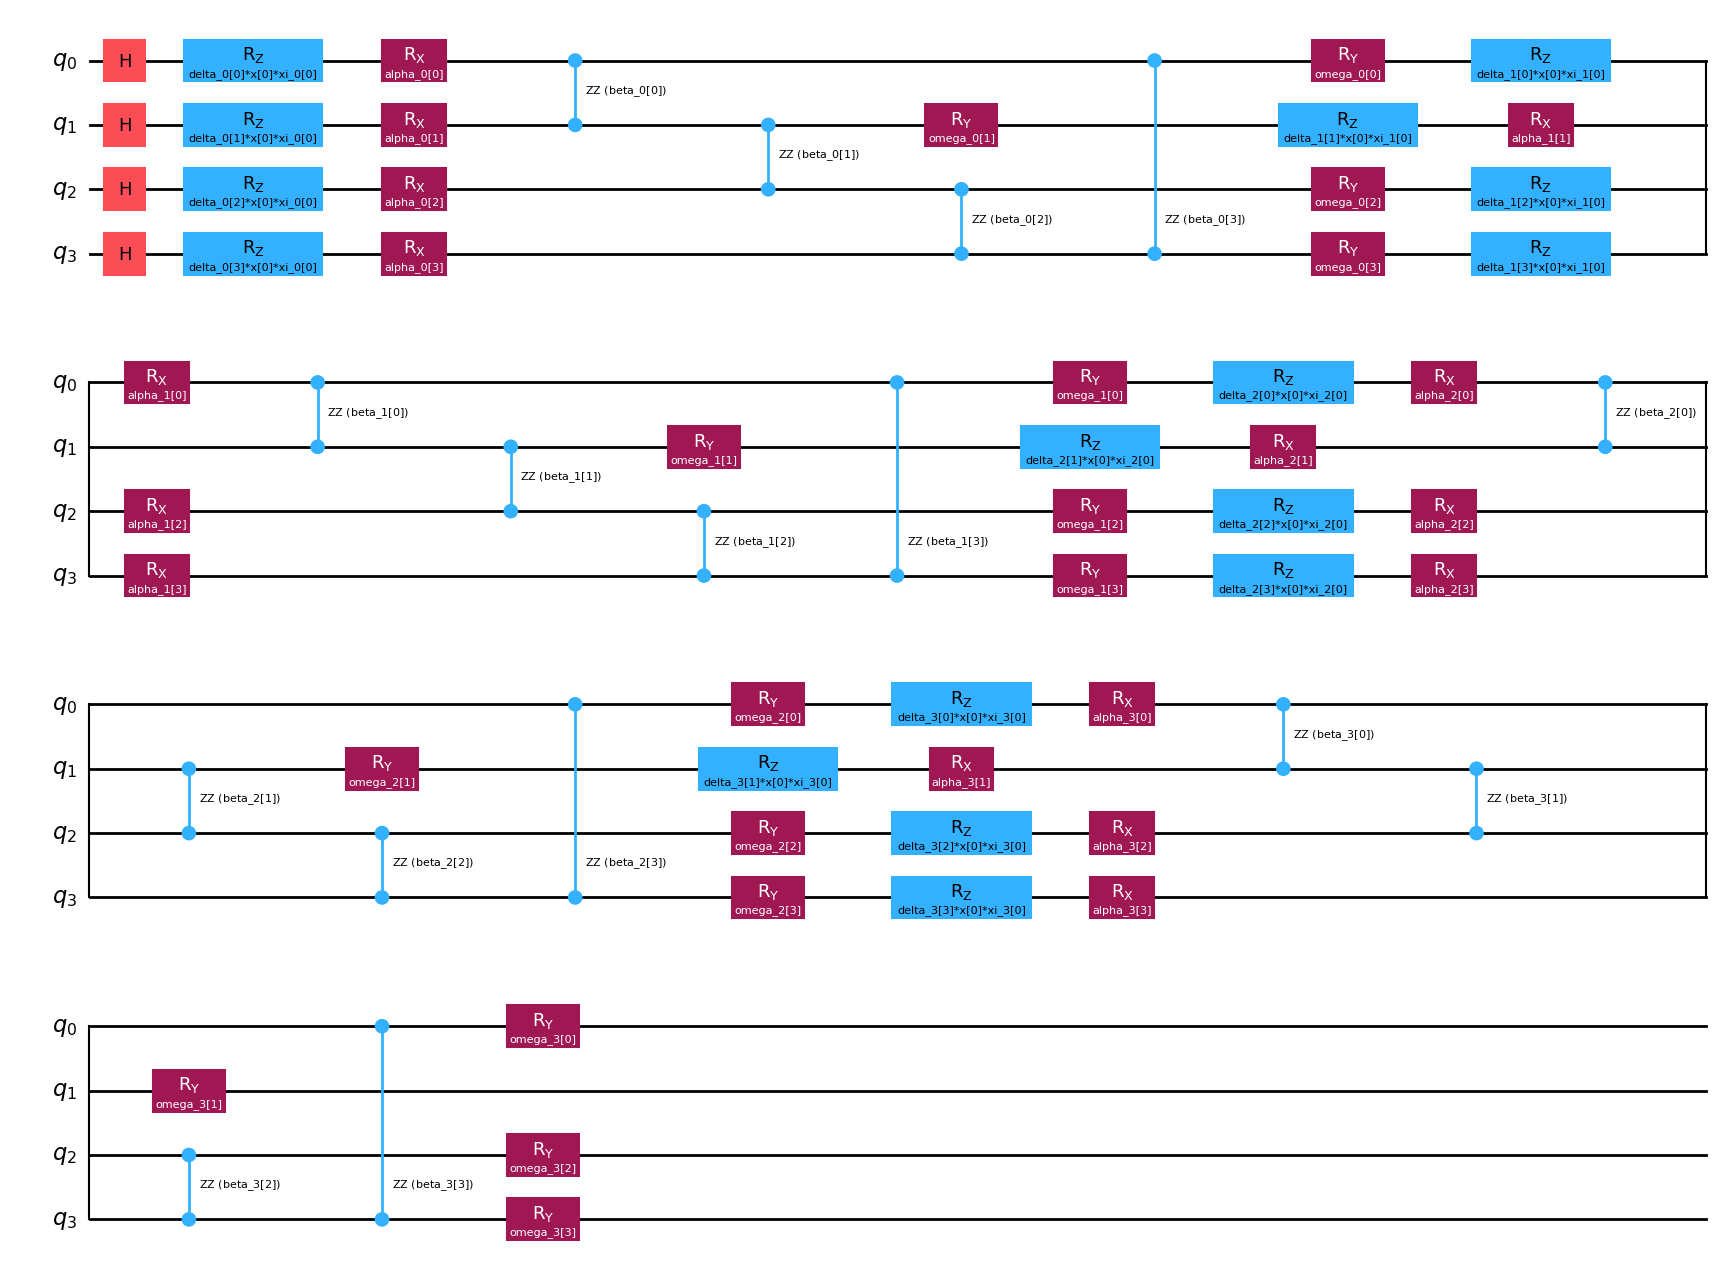

In [52]:
from src.circuits.configs import CircuitArchitecture, LayerSpec, ring_layer
from src.circuits.circuit_building import CircuitFactory

num_qubits = 4

arch = CircuitArchitecture(
    num_qubits=num_qubits,
    layers=(
        ring_layer(qubits=(0, 1, 2, 3)),
        ring_layer(qubits=(0, 1, 2, 3)),
        ring_layer(qubits=(0, 1, 2, 3)),
        ring_layer(qubits=(0, 1, 2, 3)),
    ),
    input_dim=input_dim,   # ζ = 2, say x ∈ R^2
)

arch.layers
qc = CircuitFactory.createSQPcircuit(arch)

fig = qc.draw("mpl")

fig_file = os.path.join(STORAGE_PATH, "circuits", "figs", f"ell=2_ring.pdf")

fig.savefig(fig_file, format="pdf", bbox_inches="tight")
fig

#### Parameter generation using SOBOL space filling

In [53]:
from src.circuits.experimenting import Experiment
from src.circuits.param_sampling.sobol_sampling import SobolParameterSamplingStrategy

base_seed = 12345

samplingStrategy = SobolParameterSamplingStrategy(circuit_cfg=arch, seed=base_seed)

experiment = Experiment(X=X, circuit_cfg=arch, samplingStrategy=samplingStrategy)

num_draws = 128

pubs, params_R = experiment.get_R_pubs(num_draws, seed=base_seed)

In [54]:
len(pubs), pubs[0][1].shape

(128, (500, 69))

#### How the bound circuit look like

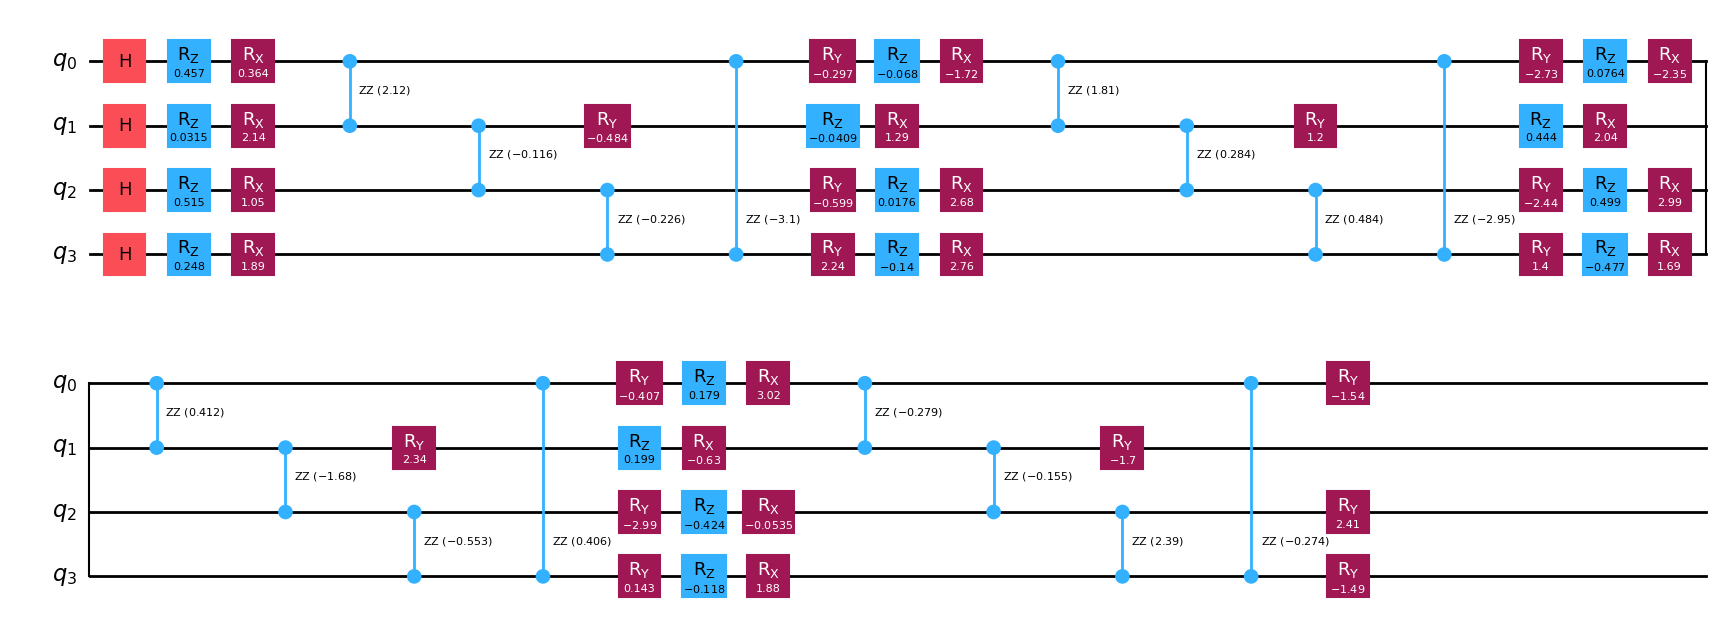

In [8]:
r, m = 0, 0
qc_bound = qc.assign_parameters(pubs[r][1][m])
fig = qc_bound.draw("mpl")
fig

## Experiment

### Exact Runner

In [55]:
from src.runners.circuit_running import ExactCircuitsRunner
from qiskit_aer import AerSimulator
from src.utils.settings import STORAGE_PATH

runner = ExactCircuitsRunner(arch=arch)

backend = AerSimulator(method="statevector", device="CPU", runtime_parameter_bind_enable=True)
results = runner.run_pubs(
    pubs=pubs,
    backend=backend,
    max_threads=None,    # Uses the maximum number of CPU cores
)

In [56]:
results_path = os.path.join(STORAGE_PATH, "results", "exact", f"noisy={noise_variance}_n_pg={len(kernel_cfgs)}_exactResults_R={num_draws}_M={M}_layers={4}.pkl")
results.save(results_path)
print(results.states.shape)

results.arch

(128, 500, 16)


CircuitArchitecture(num_qubits=4, layers=(LayerSpec(qubits=(0, 1, 2, 3), edges=((0, 1), (1, 2), (2, 3), (3, 0))), LayerSpec(qubits=(0, 1, 2, 3), edges=((0, 1), (1, 2), (2, 3), (3, 0))), LayerSpec(qubits=(0, 1, 2, 3), edges=((0, 1), (1, 2), (2, 3), (3, 0))), LayerSpec(qubits=(0, 1, 2, 3), edges=((0, 1), (1, 2), (2, 3), (3, 0)))), input_dim=1)

In [57]:
num_draws = 128

results_path = os.path.join(STORAGE_PATH, "results", "exact", f"noisy={noise_variance}_n_pg={len(kernel_cfgs)}_exactResults_R={num_draws}_M={M}_layers={4}.pkl")

from src.runners.circuit_running import ExactResults

results = ExactResults.load(results_path)

print(results.states.shape)

results.arch

(128, 500, 16)


CircuitArchitecture(num_qubits=4, layers=(LayerSpec(qubits=(0, 1, 2, 3), edges=((0, 1), (1, 2), (2, 3), (3, 0))), LayerSpec(qubits=(0, 1, 2, 3), edges=((0, 1), (1, 2), (2, 3), (3, 0))), LayerSpec(qubits=(0, 1, 2, 3), edges=((0, 1), (1, 2), (2, 3), (3, 0))), LayerSpec(qubits=(0, 1, 2, 3), edges=((0, 1), (1, 2), (2, 3), (3, 0)))), input_dim=1)

### Get correlating observables

In [58]:
from src.runners.feature_maps.utils import generate_edges_correlator_paulis

layer = ring_layer(qubits=(0, 1, 2, 3))
len(layer.qubits)


correlating_observables = generate_edges_correlator_paulis(edges=layer.edges, num_qubits=len(layer.qubits))
print(f"len(correlating_observables) = {len(correlating_observables)}")
correlating_observables[0], correlating_observables[1], correlating_observables[-2], correlating_observables[-1]

len(correlating_observables) = 24


(SparsePauliOp(['IIIX'],
               coeffs=[1.+0.j]),
 SparsePauliOp(['IIIY'],
               coeffs=[1.+0.j]),
 SparsePauliOp(['YYII'],
               coeffs=[1.+0.j]),
 SparsePauliOp(['ZZII'],
               coeffs=[1.+0.j]))

### Compute the feature maps Exactly

In [59]:
results_path = os.path.join(STORAGE_PATH, "results", "exact", f"noisy={noise_variance}_n_pg={len(kernel_cfgs)}_exactRetriever_R={num_draws}_M={M}_layers={4}.pkl")

from src.runners.feature_maps.exact_feature_map import ExactFeatureMapsRetriever

retriever = ExactFeatureMapsRetriever(arch=arch, observables=correlating_observables)
exact_fmps = retriever.get_feature_maps(results=results)

retriever.save(results_path)

exact_fmps.shape

(128, 500, 24)

In [60]:
exact_fmps[0,0]

array([-0.76193201,  0.02558185, -0.57746059,  0.18012256,  0.3164412 ,
        0.667404  ,  0.52133241,  0.09080371, -0.48970532,  0.73414901,
        0.31827006,  0.16687534, -0.18732306, -0.04727314, -0.37314434,
       -0.54146891,  0.14127775,  0.01187315, -0.14279582, -0.20938954,
       -0.35665239,  0.66670013,  0.31400534, -0.39589295])

### Compute the feature maps with Classical Shadows

In [61]:
from src.runners.feature_maps.shadow_feature_map import CSFeatureMapsRetriever
import numpy as np

num_snapshots = 10_000
cs_seed = 123

cs_retriever = CSFeatureMapsRetriever(
    arch=arch,
    observables=correlating_observables,
)

cs_fmps = cs_retriever.get_feature_maps(
    results=results,
    shots=num_snapshots,
    seed=cs_seed,
)

print(cs_fmps.shape)  # (128, 300, 24)
sup_norm = np.max(np.abs(exact_fmps - cs_fmps))
print(f"sup‖·‖_∞ = {sup_norm:.3f}")

(128, 500, 24)
sup‖·‖_∞ = 0.059


In [62]:
from src.runners.feature_maps.exact_feature_map import ExactFeatureMapsRetriever
import numpy as np

for shots in [100, 300, 1000, 3000, 5000, 10_000]:
    cs_fmps_s = cs_retriever.get_feature_maps(results=results, shots=shots, seed=cs_seed)
    sup_norm_s = np.max(np.abs(exact_fmps - cs_fmps_s))
    print(f"shots={shots:4d}, sup‖·‖_∞ = {sup_norm_s:.3f}")

shots= 100, sup‖·‖_∞ = 0.550
shots= 300, sup‖·‖_∞ = 0.348
shots=1000, sup‖·‖_∞ = 0.187
shots=3000, sup‖·‖_∞ = 0.108
shots=5000, sup‖·‖_∞ = 0.084
shots=10000, sup‖·‖_∞ = 0.059


# Learning with Multiple Kernel Learning and trainable noise

#### Compute cosine similarity grams

In [63]:
eps = 1e-12
norms = np.linalg.norm(cs_fmps, axis=-1, keepdims=True)  # (R, M, 1)
fmps_unit = cs_fmps / (norms + eps)
cos_grams = fmps_unit @ np.transpose(fmps_unit, (0, 2, 1))  # cosine similarity in [-1, 1]
gram_01  = 0.5 * (cos_grams + 1.0)                          # similarity in [0, 1]
cs_grams = gram_01.reshape(num_draws, 1, M, M)
cs_grams.shape

(128, 1, 500, 500)

### Train the approx soft MKL

In [67]:
from src.models.mk_learner import default_approx_rank, default_n_hutchinson_probes
import numpy as np

approx_seed = 1028
train_test_split = 0.75

M_train = int(np.floor(train_test_split * M))

approx_rank=32
n_hutchinson_probes=16

M_train, approx_rank, n_hutchinson_probes

(375, 32, 16)

#### Compute approx ranks and hutchinson_probes

In [70]:
from src.models.noisy.noisy_soft_mklearner import NoisySoftmaxMKLearner

soft_approx_mkl = NoisySoftmaxMKLearner(
    arch=arch,
    grams=cs_grams,
    X=X,
    Y=Y,
    train_test_split=train_test_split,
    jitter=0.0,
    noise_variance=1.0,         # initial guess for σ^2
    fit_noise_variance=True,    # <- learn σ_g^2 per GP
    use_approx_grad=True,
    approx_rank=approx_rank,
    n_hutchinson_probes=n_hutchinson_probes,
    approx_seed=1028,
)

from src.utils.settings import STORAGE_PATH
file = os.path.join(STORAGE_PATH, "results", "approx", "soft", f"fit_noise_M={M}_mkl_untrained_layers={4}.pkl")
soft_approx_mkl.save(file)

#### Train the model

In [71]:
_ = soft_approx_mkl.fit(max_iter=400, tol=1e-4, verbose=True, n_jobs=1, n_coord_steps=3)

from src.utils.settings import STORAGE_PATH
file = os.path.join(STORAGE_PATH, "results", "approx", "soft", f"fit_noise_M={M}_mkl_trained_layers={4}.pkl")
soft_approx_mkl.save(file)


[SoftMKL] ==== Coordinate step 1 / 3 ====

[SoftMKL] [coord 1] === GP 0 / 2 ===
[SoftMKL] [GP 0] iter 000  L=-13.478339  rel_impr=4.577e-04
[SoftMKL] [GP 0] iter 001  L=-13.472235  rel_impr=4.529e-04
[SoftMKL] [GP 0] iter 002  L=-13.466196  rel_impr=4.483e-04
[SoftMKL] [GP 0] iter 003  L=-13.460217  rel_impr=4.439e-04
[SoftMKL] [GP 0] iter 004  L=-13.454298  rel_impr=4.398e-04
[SoftMKL] [GP 0] iter 005  L=-13.448435  rel_impr=4.358e-04
[SoftMKL] [GP 0] iter 006  L=-13.442626  rel_impr=4.320e-04
[SoftMKL] [GP 0] iter 007  L=-13.436868  rel_impr=4.283e-04
[SoftMKL] [GP 0] iter 008  L=-13.431159  rel_impr=4.249e-04
[SoftMKL] [GP 0] iter 009  L=-13.425496  rel_impr=4.216e-04
[SoftMKL] [GP 0] iter 010  L=-13.419878  rel_impr=4.185e-04
[SoftMKL] [GP 0] iter 011  L=-13.414302  rel_impr=4.155e-04
[SoftMKL] [GP 0] iter 012  L=-13.408766  rel_impr=4.127e-04
[SoftMKL] [GP 0] iter 013  L=-13.403268  rel_impr=4.100e-04
[SoftMKL] [GP 0] iter 014  L=-13.397806  rel_impr=4.075e-04
[SoftMKL] [GP 0] it

### Explore results

#### Visualization

In [72]:
soft_approx_metrics = soft_approx_mkl.get_train_test_metrics()

# metrics = mkl_exact.get_train_test_metrics()

print("train log-marginals:", soft_approx_metrics["train_log_marginal_likelihood"])
print("train log-marginals per point:", soft_approx_metrics["train_log_marginal_likelihood_per_point"])

print("test log pred density (sum):", soft_approx_metrics["test_log_predictive_density"])
print("test avg NLPD:", soft_approx_metrics["test_avg_nlpd"])

print("RMSE test:", soft_approx_metrics["rmse_test"])
print("MAE test:", soft_approx_metrics["mae_test"])

print("z mean:", soft_approx_metrics["z_mean"])
print("z var:", soft_approx_metrics["z_var"])

print("coverage ±1σ:", soft_approx_metrics["coverage_1sigma"])
print("coverage ±2σ:", soft_approx_metrics["coverage_2sigma"])

print("weights shape:", soft_approx_mkl.weights.shape)  # (num_gps, R, B)

train log-marginals: [930.469419   644.47685192 900.85566087]
train log-marginals per point: [2.48125178 1.71860494 2.40228176]
test log pred density (sum): [198.05889222 125.18184717 201.91157002]
test avg NLPD: [-1.58447114 -1.00145478 -1.61529256]
RMSE test: [0.04900252 0.08321435 0.04719753]
MAE test: [0.03886606 0.06505203 0.03869604]
z mean: [0.07533646 0.00802019 0.14850974]
z var: [1.2331088  1.6013182  1.29413152]
coverage ±1σ: [0.656 0.632 0.576]
coverage ±2σ: [0.912 0.904 0.92 ]
weights shape: (3, 128, 1)


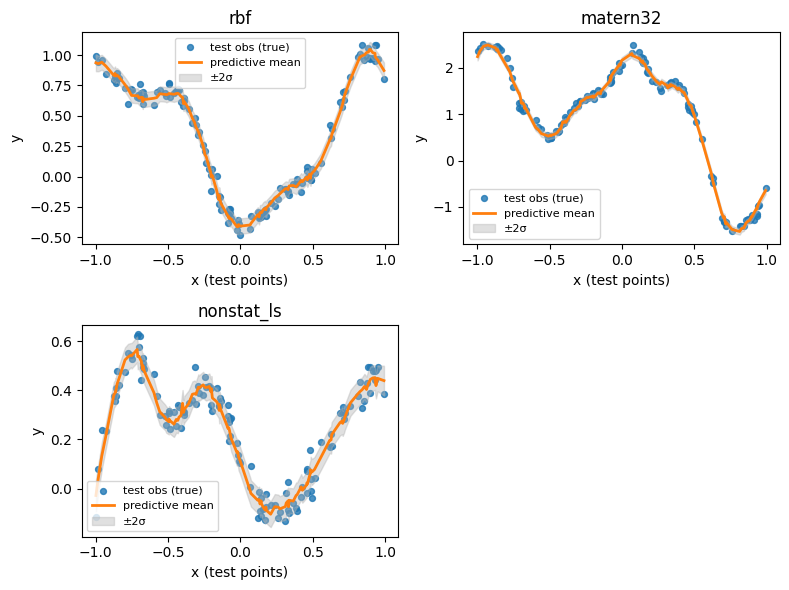

In [79]:
means, vars_ = soft_approx_mkl.infer()
means.shape, vars_.shape

from viz.models.mkl_viz import draw_test_only_predictions

fig = draw_test_only_predictions(
    data=data,
    means=means,
    vars_=vars_,
    test_idx=soft_approx_mkl.test_idx,
    kernel_cfgs=kernel_cfgs,   # optional, for titles
)

fig_file = os.path.join(STORAGE_PATH, "results", "approx", "soft", "figs", f"M={M}_vis_test_plots_layers={4}.pdf")

fig.savefig(fig_file, format="pdf", bbox_inches="tight")

#### Metrics Computation

In [81]:
X = data["inputs"]         # shape (M,) since input_dim = 1
X_test = X[soft_approx_mkl.test_idx]          # test inputs

from results.metrics.kernel_similarity import build_true_test_grams

true_test_grams = build_true_test_grams(
    data=data,
    kernel_cfgs=kernel_cfgs,
    test_idx=soft_approx_mkl.test_idx,
)

print(f"true_test_grams.shape = {true_test_grams.shape}")

kernel_metrics = soft_approx_mkl.get_kernel_similarity_metrics(
    reference_kernels=true_test_grams,
    subset="test",
)

# print("Frobenius relative error per GP:", kernel_metrics["kernel_frobenius_rel_error"])
print("Kernel alignment per GP:", kernel_metrics["kernel_alignment"])

true_test_grams.shape = (3, 125, 125)
Kernel alignment per GP: [0.97914153 0.99196248 0.9537627 ]


In [ ]:
0.9791

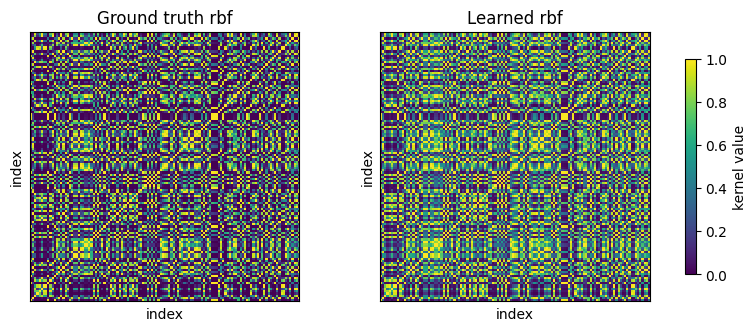

In [75]:
from viz.models.mkl_viz import draw_kernel_heatmap_comparison

# learned kernels on the test set
learned_test_grams = soft_approx_mkl.get_mixed_kernels(subset="test", zero_one_scale=True)

gp_idx = 0  # rbf GP

true_K_rbf = true_test_grams[gp_idx]              # (M_test, M_test)
learned_K_rbf = learned_test_grams[gp_idx]        # (M_test, M_test)

fig = draw_kernel_heatmap_comparison(true_K_rbf, learned_K_rbf, gp_name="rbf")

fig_file = os.path.join(STORAGE_PATH, "results", "approx", "soft", "figs", f"M={M}_heat_map_rbf.pdf")

fig.savefig(fig_file, format="pdf", bbox_inches="tight")

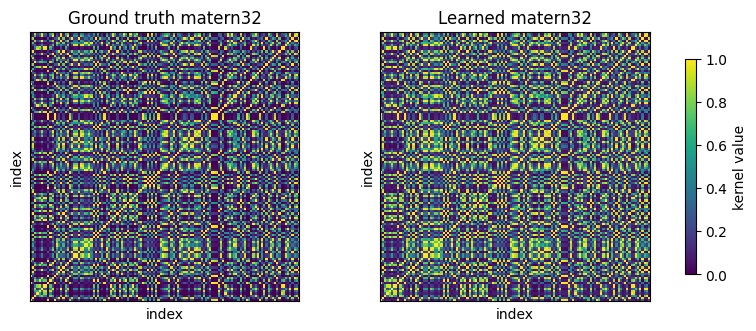

In [76]:
from viz.models.mkl_viz import draw_kernel_heatmap_comparison

# learned kernels on the test set
learned_test_grams = soft_approx_mkl.get_mixed_kernels(subset="test", zero_one_scale=True)

gp_idx = 1  # rbf GP

true_K_rbf = true_test_grams[gp_idx]              # (M_test, M_test)
learned_K_rbf = learned_test_grams[gp_idx]        # (M_test, M_test)

fig = draw_kernel_heatmap_comparison(true_K_rbf, learned_K_rbf, gp_name="matern32")

fig_file = os.path.join(STORAGE_PATH, "results", "approx", "soft", "figs", f"M={M}_heat_map_mat.pdf")

fig.savefig(fig_file, format="pdf", bbox_inches="tight")

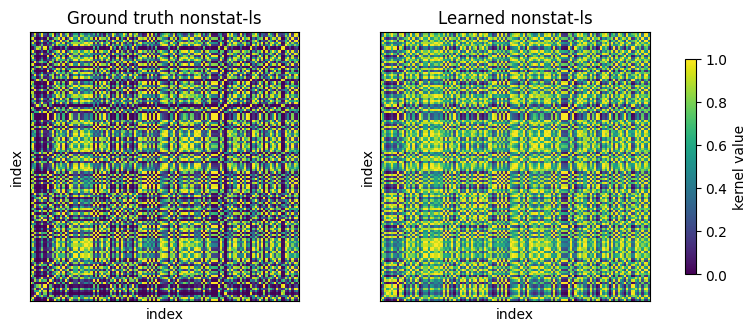

In [77]:
from viz.models.mkl_viz import draw_kernel_heatmap_comparison

# learned kernels on the test set
learned_test_grams = soft_approx_mkl.get_mixed_kernels(subset="test", zero_one_scale=True)

gp_idx = 2  # rbf GP

true_K_rbf = true_test_grams[gp_idx]              # (M_test, M_test)
learned_K_rbf = learned_test_grams[gp_idx]        # (M_test, M_test)

fig = draw_kernel_heatmap_comparison(true_K_rbf, learned_K_rbf, gp_name="nonstat-ls")

fig_file = os.path.join(STORAGE_PATH, "results", "approx", "soft", "figs", f"M={M}_heat_map_non-stat.pdf")

fig.savefig(fig_file, format="pdf", bbox_inches="tight")

# ...